## **Perceptron Multicamadas (MLP)**

Uma rede feedforward com $L$ camadas computa uma função $y_k(\mathbf{x}, \mathbf{w})$ onde $\mathbf{w}$ é o vetor de todos os parâmetros.

A ativação de cada unidade na camada $\ell$ é dada por:

$$
a_j^{(\ell)} = \sum_i w_{ji}^{(\ell)} \cdot z_{i}^{(\ell-1)}
\quad
\text{ e }
\quad
z_{j}^{(\ell)} = h\left(a_j^{(\ell)}\right)
$$

onde:

* A função $h(\cdot)$ é a função de ativação ($\tanh$ ou sigmoide)
* Os valores $z_i^{(0)} = x_i$ são as entradas
* O índice $w_{ji}$ segue a convenção "unidade destino primeiro, unidade origem depois".

Dado um conjunto de observações

$$
\mathcal{D} = \{(\mathbf{x}_n, t_n)\}_{n=1}^N
\quad
\text{onde}
\quad \mathbf{x}_n \in \mathbb{R}^{D}
$$

definimos a função de erro como a soma sobre os exemplos:

$$
E(\mathbf{w}) = \sum_{n=1}^{N} E_n(\mathbf{w})
$$

para regressão:

$$
E_n(\mathbf{w}) = \dfrac{1}{2} \sum_k (y_k(\mathbf{x}_n, \mathbf{w}) - t_{nk})^{2}
$$

para classificação:

$$
E_n(\mathbf{w}) = -\sum_k t_{nk} \ln y_k(\mathbf{x}_n)
$$

Atualizamos o valor dos pesos usando SGD dado por:

$$
\mathbf{w}^{(\tau + 1)} = \mathbf{w}^{(\tau)} - \eta\,\nabla E(\mathbf{w}^{(\tau)})
$$

precisamos então determinar o valor de $\nabla_{\mathbf{w}}\,E$.

O cálculo do gradiente requer calcular a derivada de $E_n$ em relação a cada peso $w_{ji}^{(\ell)}$.

Usando a regra da cadeia para derivadas parciais, temos que:

$$
\dfrac{\partial E_n}{\partial w_{ji}^{(\ell)}} = \dfrac{\partial E_n}{\partial a_j^{(\ell)}} \cdot \dfrac{\partial a_j^{(\ell)}}{\partial w_{ji}^{(\ell)}}
$$

Definimos então a seguinte notação:

$$
\delta_j^{(\ell)} \equiv \dfrac{\partial E_n}{\partial a_j^{(\ell)}}
$$

Dado que $a_j^{(\ell)} = \sum_i w_{ji}^{(\ell)} \cdot z_{i}^{(\ell-1)}$, temos que $\dfrac{\partial a_j^{(\ell)}}{\partial w_{ji}^{(\ell)}} = z_i^{(\ell-1)}$.

Substituindo os resultados na regra da cadeia, temos:
$$
\dfrac{\partial E_n}{\partial w_{ji}^{(\ell)}} = \delta_j^{(\ell)} \cdot z_i^{(\ell-1)}
$$

o problema agora consiste em como calcular $\delta_j^{(\ell)}$ para todas as camadas.

### **Backpropagation**

O algoritmo backpropagation calcula eficientemente $\delta_j^{(\ell)}$
para todas as camadas, explorando a estrutura do grafo em duas fases:

- **Forward pass**: propaga o sinal de entrada $\mathbf{x}_n$ camada a camada, armazenando
  as pré-ativações $a_j^{(\ell)}$ e as ativações $z_j^{(\ell)}$.
- **Backward pass**: propaga o sinal de erro da saída em direção à entrada,
  calculando os $\delta_j^{(\ell)}$ por recorrência.

Segue então o passo a passo do backpropagation:

**Passo 1 — Forward pass**

Propagar $\mathbf{x}_n$ pela rede, calculando e **armazenando** para cada camada $\ell = 1, \ldots, L$:

$$
a_j^{(\ell)} = \sum_i w_{ji}^{(\ell)} z_i^{(\ell-1)}
\quad
\text{ e }
\quad
z_j^{(\ell)} = h\left(a_j^{(\ell)}\right)
$$

Os valores $z_j^{(\ell)}$ precisam ser retidos em memória pois são usados no Passo 4.

**Passo 2 — Deltas na camada de saída**

Para a camada de saída $L$, o delta é obtido do seguinte modo:

$$
\delta_k^{(L)} = y_k - t_k
$$

**Passo 3 — Retropropagação dos deltas**

Para as camadas $\ell = (L-1), \ldots, 1$, calculamos os deltas usando a equação fundamental:

$$
\delta_j^{(\ell)} = h'\!\left(a_j^{(\ell)}\right) \sum_k w_{kj}^{(\ell+1)}\, \delta_k^{(\ell+1)}
$$


**Passo 4 — Cálculo dos gradientes**

Com os deltas calculados, o gradiente em relação a cada peso é:

$$
\frac{\partial E_n}{\partial w_{ji}^{(\ell)}} = \delta_j^{(\ell)} \cdot z_i^{(\ell-1)}
$$

**Passo 5 — Atualização dos pesos**

Acumulando os gradientes sobre **todos os exemplos** antes de atualizar (*batch gradient descent*):

$$
w_{ji}^{(\ell)} \;\leftarrow\;  w_{ji}^{(\ell)} - \eta \sum_n \delta_{j,n}^{(\ell)}\, z_{i,n}^{(\ell-1)}
$$

Ou atualizando imediatamente após **cada exemplo** (*SGD puro*):

$$
w_{ji}^{(\ell)} \;\leftarrow\;  w_{ji}^{(\ell)} - \eta\; \delta_{j,n}^{(\ell)}\, z_{i,n}^{(\ell-1)}
$$

A implementação abaixo usa SGD puro.

> BISHOP, Christopher M. Pattern Recognition and Machine Learning. New York: Springer, 2006. Seção 5.3, p. 241.

> FACELI, Katti; LORENA, Ana Carolina; GAMA, João; CARVALHO, André C. P. L. F. de. Inteligência Artificial: Uma Abordagem de Aprendizado de Máquina. Rio de Janeiro: LTC, 2011. Seções 7.1.4 e 7.1.5, p. 115 e 117.

## **Implementação de MLP: Aprendendo XOR**



### **Dataset**

A função **XOR** recebe dois valores $x_1$ e $x_2$, pertencendes ao conjunto $\{0, 1\}$, e mapeia o resultado de acordo com a saída apresentada:

In [35]:
import numpy as np

X_raw = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
  ])

T = np.array([
      [0],
      [1],
      [1],
      [0]
    ])

### **Funções auxiliares**

Usamos a sigmoide definida abaixo:

$$
\sigma(a) = \dfrac{1}{1 + e^{-a}}
$$

como função de ativação em ambas as camadas, pois ela é contínua, diferenciável e estritamente crescente.

Sua derivada tem uma forma conveniente dada por:

$$
\sigma'(a) = \sigma(a)\,(1 - \sigma(a))
$$

In [36]:
def sigmoid(a):
    return 1.0 / (1.0 + np.exp(-a))

def sigmoid_deriv(a):
    s = sigmoid(a)
    return s * (1 - s)

### **Definição da Arquitetura e Inicialização dos pesos**

O XOR não é linearmente separável, então precisamos de pelo menos uma camada oculta.

Usamos uma rede com três camadas:

* **Entrada**: 2 unidades ($x_1$, $x_2$)
* **Oculta**: 2 unidades com ativação sigmoide
* **Saída**: 1 unidade com ativação sigmoide

É bom lembrar que o bias é absorvido nos pesos aumentando cada vetor de ativações com uma componente $z_0 = 1$.

As dimensões resultantes são:

* `W1`: shape $(2, 3)$ — 2 destinos, 3 origens (bias + $x_1$ + $x_2$)
* `W2`: shape $(1, 3)$ — 1 destino,  3 origens (bias + $z_1$ + $z_2$)

Os pesos são inicializados com valores aleatórios pequenos, garantindo que cada unidade oculta aprenda uma representação distinta.

In [37]:
np.random.seed(42)

W1 = np.random.randn(2, 3) * 0.1
W2 = np.random.randn(1, 3) * 0.1

### **Forward pass**

A função `augment` prefixa o valor $1$ ao vetor de ativações, implementando o bias absorvido.

Para cada camada calculamos a **pré-ativação** e a **ativação** (Passo 1):

$$
\mathbf{a}^{(\ell)} = \mathbf{W}^{(\ell)}\mathbf{z}^{(\ell-1)}
\quad
\mathbf{z}^{(\ell)} = \sigma(\mathbf{a}^{(\ell)})
$$


In [38]:
def augment(z):
    return np.concatenate([[1], z])

def forward(x):
    z0 = augment(x)
    a1 = W1 @ z0
    z1 = augment(sigmoid(a1))
    a2 = W2 @ z1
    y  = sigmoid(a2)
    return y, a1, z1, a2

### **Backward pass**

Calculamos os deltas de trás para frente e em seguida os gradientes.

Primeiro o **delta da camada de saída** (Passo 2):

$$\delta^{(2)} = y - t$$

Em seguida o **delta na camada oculta** (Passo 3):
$$
\delta_j^{(1)} = \sigma'(a_j^{(1)}) \sum_k w_{kj}^{(2)}\, \delta_k^{(2)}
$$

Usamos `W2[:, 1:]` para descartar a coluna do bias de `W2`.

Por fim, realizamos o cálculo dos **Gradientes** (Passo 4):

$$
\frac{\partial E_n}{\partial w_{ji}^{(\ell)}} = \delta_j^{(\ell)} \cdot z_i^{(\ell-1)}
$$

Note que o produto externo $\delta \otimes z^\top$ produz uma matriz com a mesma forma de $\mathbf{W}^{(\ell)}$, onde a entrada $(j, i)$ é exatamente $\delta_j^{(\ell)} \cdot z_i^{(\ell-1)}$.

In [39]:
def backward(x, t):
    y, a1, z1, a2 = forward(x)

    delta2 = y - t

    delta1 = sigmoid_deriv(a1) * (W2[:, 1:].T @ delta2)

    dW2 = np.outer(delta2, z1)
    dW1 = np.outer(delta1, augment(x))

    return dW1, dW2

### **Treinamento**

Usamos SGD puro, onde para cada exemplo, calculamos os gradientes via
`backward` e atualizamos os pesos imediatamente (Passo 5):

$$
\mathbf{W}^{(\ell)} \leftarrow \mathbf{W}^{(\ell)} - \eta \cdot \nabla_{\mathbf{W}^{(\ell)}} E_n
$$

O erro $E = \displaystyle\sum_n [t_n \ln y_n + (1 - t_n)\ln (1 - y_n)]$ é acumulado apenas para
monitoramento, mas não afeta a atualização dos pesos.

In [40]:
def binary_cross_entropy(y, t, eps=1e-15):
    y = np.clip(y, eps, 1 - eps)
    return -(t * np.log(y) + (1 - t) * np.log(1 - y))[0]

In [41]:
def train_MLP(X_raw, T, eta=0.5, epochs=10000):
    global W1, W2
    losses = []

    for epoch in range(epochs):
        loss = 0.0
        for i in range(len(X_raw)):
            dW1, dW2 = backward(X_raw[i], T[i])
            W1 -= eta * dW1
            W2 -= eta * dW2
            y, *_ = forward(X_raw[i])
            loss += binary_cross_entropy(y, T[i])

        losses.append(loss)

        if epoch % 1000 == 0:
            print(f"Época {epoch:5d}  |  E = {loss:.6f}")

    return losses

losses = train_MLP(X_raw, T)

Época     0  |  E = 2.358494
Época  1000  |  E = 0.554761
Época  2000  |  E = 0.018448
Época  3000  |  E = 0.009295
Época  4000  |  E = 0.006201
Época  5000  |  E = 0.004648
Época  6000  |  E = 0.003715
Época  7000  |  E = 0.003094
Época  8000  |  E = 0.002650
Época  9000  |  E = 0.002317


#### **Curva de Aprendizado**

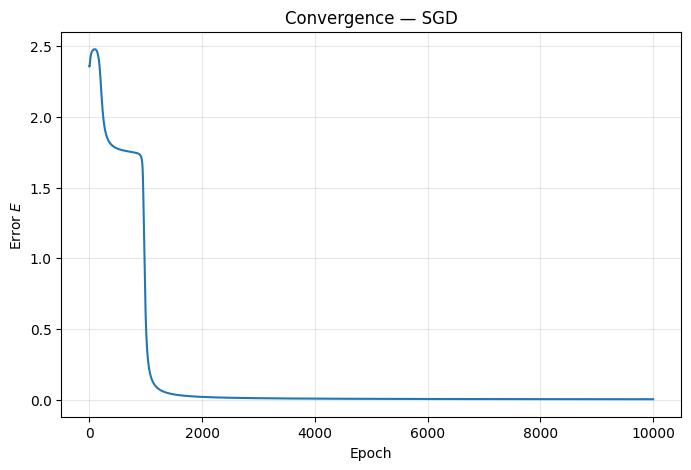

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel(r"Error $E$")
plt.title("Convergence — SGD")
plt.grid(True, alpha=0.3)

plt.show()

In [43]:
import pandas as pd

results = []
for i in range(len(X_raw)):
    y, *_ = forward(X_raw[i])
    results.append({
        "x1": int(X_raw[i][0]),
        "x2": int(X_raw[i][1]),
        "t":  int(T[i][0]),
        "y":  round(float(y[0]), 4),
        "ŷ":  int(y[0] >= 0.5)
    })

df = pd.DataFrame(results)
df

,x1,x2,t,y,ŷ
0,0,0,0,0.0004,0
1,0,1,1,0.9995,1
2,1,0,1,0.9995,1
3,1,1,0,0.0007,0
